## **자전거 대여량 예측**


#### **데이터, 모듈 가져오기**

In [ ]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

gdown.download('https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG', 'train.csv', quiet=False)
train = pd.read_csv("train.csv") 
train.info()


Downloading...
From: https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG
To: c:\Users\singf\Desktop\아이펠 모음\bike_regression\train.csv
100%|██████████| 648k/648k [00:00<00:00, 770kB/s]

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


#### **컬럼을 자료형으로 변환, 컬럼 생성**

In [ ]:
# datetime 컬럼을 문자열 → datetime 자료형으로 변환
train['datetime'] = pd.to_datetime(train['datetime'])

# datetime에서 연·월·일·시·분·초를 각각 별도 컬럼으로 추출
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()


<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-null  int32

#### **데이터 개수 시각화하기**

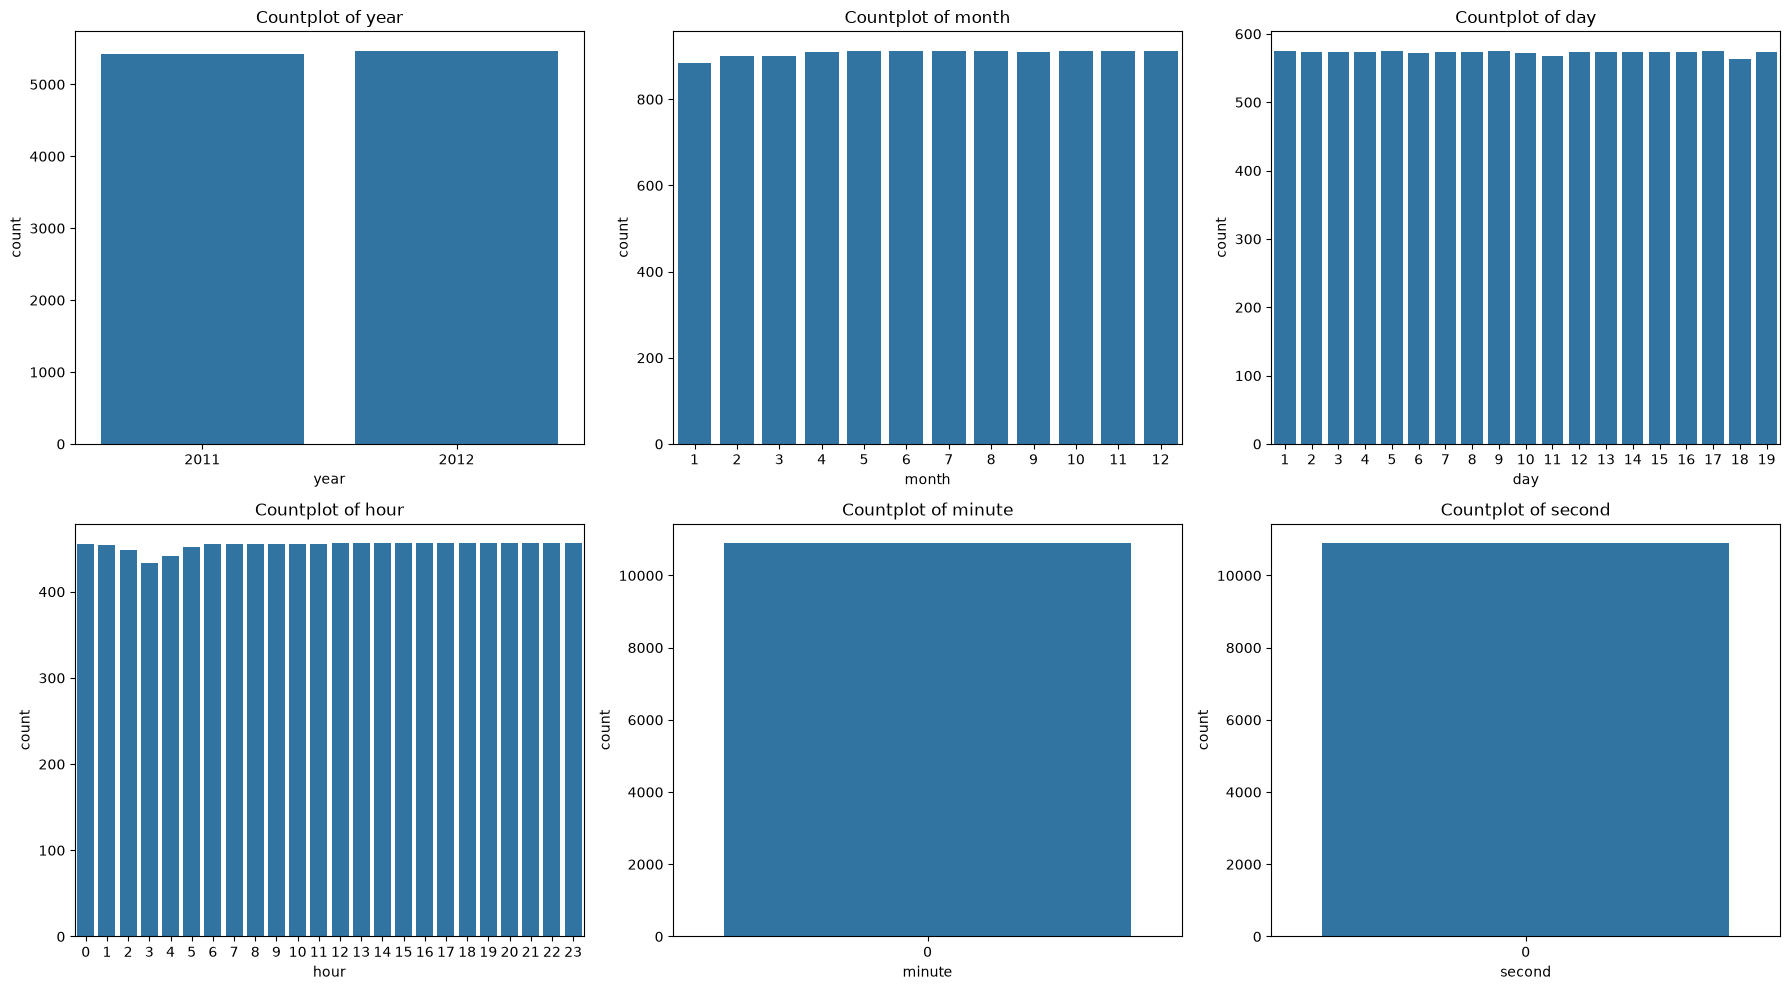

In [ ]:
# 2행 3열, 총 6개의 서브플롯 생성
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# 시각화할 시간 관련 컬럼을 리스트로 두기
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']


for ax, col in zip(axs.flatten(), cols): 
    sns.countplot(x=col, data=train, ax=ax) # x축 값별 행 개수
    ax.set_title(f'Countplot of {col}')
  
plt.tight_layout() # 그래프 간격 조정
plt.show()

#### **컬럼 선택 및 train/test 데이터 분리**

In [ ]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split

# 전체 데이터를 학습 80% / 테스트 20%로 분리 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### **LinearRegression 모델 학습**

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train); # decode 찐빠나서 세미콜론 덧붙임.

#### **학습된 모델로 X_test에 대한 예측값 출력 및 손실함수값 계산**

In [ ]:
from sklearn.metrics import mean_squared_error

# 테스트 데이터에 대한 예측값 생성
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.90181443557
RMSE: 141.28659460272786


#### **x축은 temp 또는 humidity로, y축은 count로 예측 결과 시각화하기**


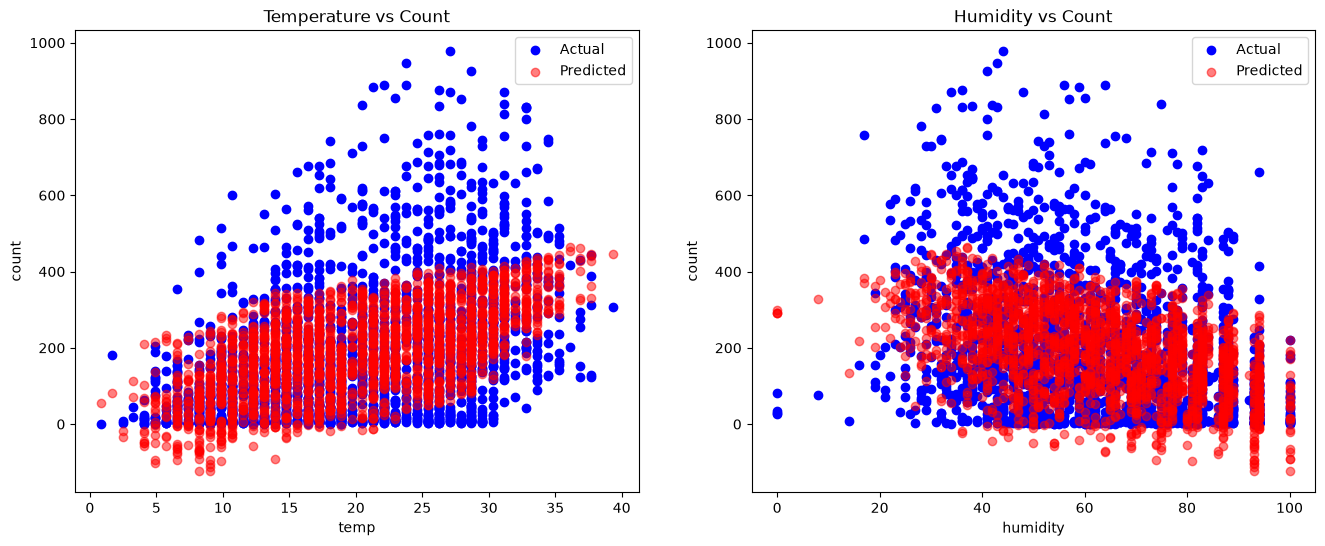

In [ ]:
# temp, humidity 각각에 대해 실제값 vs 예측값 비교
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화 
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()